In [91]:
# 安装系统库
!apt-get -y update
!apt-get -y install libgeos-dev proj-bin proj-data libproj-dev

# 安装 Python 库
!pip -q install xarray cartopy matplotlib numpy


Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [92]:
import os
from getpass import getpass
import ftplib
from urllib.parse import urlparse
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

In [93]:
def _download_file(ftp:str, filename:str, target_directory:str):
    print(f"Download file: {filename}")
    try:
        local_filepath = os.path.join(target_directory, filename)
        with open(local_filepath, 'wb') as file:
            ftp.retrbinary('RETR %s' % filename, file.write)
            return local_filepath
    except Exception as e:
        print(f"Error downloading {filename}: {e}")

def _get_last_version_filename(filenames):
    versions = {int(f[-5:-3]): f for f in filenames}
    return versions[max(versions.keys())]

def _select_filename(filenames, only_last):
    if not only_last: return filenames
    return [_get_last_version_filename(filenames)]

def ftp_download_files(ftp_path, level, variant, cycle_numbers, half_orbits, output_dir, only_last=True):
    ftpAVISO = 'ftp-access.aviso.altimetry.fr'
    try:
        with ftplib.FTP(ftpAVISO) as ftp:
            # 直接用写死的用户名和密码
            ftp.login("williamedge88@gmail.com", "Wkpbck")
            ftp.cwd(ftp_path)
            print(f"Connection Established {ftp.getwelcome()}")
            downloaded_files = []

            for cycle in cycle_numbers:
                cycle_str = '{:03d}'.format(cycle)
                cycle_dir = f'cycle_{cycle_str}'
                print(ftp_path+cycle_dir)
                ftp.cwd(cycle_dir)

                for half_orbit in half_orbits:
                    half_orbit_str = '{:03d}'.format(half_orbit)
                    pattern = f'SWOT_{level}_LR_SSH_{variant}_{cycle_str}_{half_orbit_str}'
                    filenames = []
                    try:
                        filenames = ftp.nlst(f'{pattern}_*')
                        if level == "L3":
                            only_last = False
                        filenames = _select_filename(filenames, only_last)
                    except Exception as e:
                        print(e)
                        print(f"No pass {half_orbit}")

                    local_files = [_download_file(ftp, f, output_dir) for f in filenames]
                    downloaded_files += [f for f in local_files if f]

                ftp.cwd('../')

            return downloaded_files

    except ftplib.error_perm as e:
        print(f"FTP error: {e}")
    except Exception as e:
        print(f"Error: {e}")


def _normalized_ds(ds, lon_min, lon_max):
    lon = ds.longitude.values
    lon[lon < lon_min] += 360
    lon[lon > lon_max] -= 360
    ds.longitude.values = lon
    return ds

def _subset_ds(file, variables, lon_range, lat_range, output_dir):
    print(f"Subset dataset: {file}")
    swot_ds = xr.open_dataset(file)
    swot_ds = swot_ds[variables]
    swot_ds.load()

    ds = _normalized_ds(swot_ds.copy(), -180, 180)

    mask = (
        (ds.longitude <= lon_range[1])
        & (ds.longitude >= lon_range[0])
        & (ds.latitude <= lat_range[1])
        & (ds.latitude >= lat_range[0])
    ).compute()

    swot_ds_area = swot_ds.where(mask, drop=True)

    if swot_ds_area.sizes['num_lines'] == 0:
        print(f'Dataset {file} not matching geographical area.')
        return None

    for var in list(swot_ds_area.keys()):
        swot_ds_area[var].encoding = {'zlib':True, 'complevel':5}

    filename = f"subset_{os.path.basename(urlparse(file).path)}"

    print(f"Store subset: {filename}")
    filepath = os.path.join(output_dir, filename)
    swot_ds_area.to_netcdf(filepath, mode='w')

    return filepath


def subset_files(filenames, variables, lon_range, lat_range, output_dir):
    """ Subset datasets with geographical area.
    Args:
        filenames
            the filenames of datasets to subset
        variables
            variables to select
        lon_range
            the longitude range
        lat_range
            the latitude range
        output_dir
            output directory
    Returns:
        The list of subsets files.
    """
    return [subset_file for subset_file in [_subset_ds(f, variables, lon_range, lat_range, output_dir) for f in filenames] if subset_file is not None]


def plot_datasets(filenames, variable, extent=None):
    cb_args = dict(
        add_colorbar=True,
        cbar_kwargs={"shrink": 0.3}
    )

    plot_kwargs = dict(
        x="longitude",
        y="latitude",
        cmap="Spectral_r",
        vmin=-0.2,
        vmax=0.2,
    )

    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
    if extent: ax.set_extent(extent)

    for filename in filenames:
        ds = xr.open_dataset(filename)
        ds[variable].plot.pcolormesh(
            ax=ax,
            **plot_kwargs,
            **cb_args)
        cb_args=dict(add_colorbar=False)

    ax.coastlines()
    ax.gridlines(draw_labels=True)

# ② 在下载函数里也兜底创建目录
def _download_file(ftp, filename: str, target_directory: str):
    try:
        os.makedirs(target_directory, exist_ok=True)  # <<< 新增
        local_filepath = os.path.join(target_directory, filename)
        print(f"Download file: {filename}")
        with open(local_filepath, 'wb') as file:
            ftp.retrbinary(f'RETR {filename}', file.write)
        return local_filepath
    except Exception as e:
        print(f"Error downloading {filename}: {e}")
        return None


In [94]:
output_dir = "downloads"
os.makedirs(output_dir, exist_ok=True)

In [95]:
#username = input("Enter username:")


In [96]:
#password = getpass(f"Enter password for {username}:")


In [97]:
version = 'v2_0_1'

region = 'ningaloo'
localbox = [111, 114, -25, -20]


In [98]:
ftp_path = '/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Expert/'

# For selecting files with a regex pattern
# Basic, Expert, WindWave, Unsmoothed
variant = "Expert"
# L2, L3
level = "L3"

In [99]:
variables = ['time', 'ssha_filtered']

In [100]:
# Define cycles and half_orbits numbers to download
cycle_numbers = [29]
pass_numbers = [62]

Connection Established 220 192.168.10.119 FTP server ready
/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Expert/cycle_029
Download file: SWOT_L3_LR_SSH_Expert_029_062_20250226T145417_20250226T154543_v2.0.1.nc
Downloaded: ['downloads/SWOT_L3_LR_SSH_Expert_029_062_20250226T145417_20250226T154543_v2.0.1.nc']
Subset dataset: downloads/SWOT_L3_LR_SSH_Expert_029_062_20250226T145417_20250226T154543_v2.0.1.nc
Store subset: subset_SWOT_L3_LR_SSH_Expert_029_062_20250226T145417_20250226T154543_v2.0.1.nc


/tmp/ipython-input-871737252.py:117: SerializationWarning: saving variable latitude with floating point data as an integer dtype without any _FillValue to use for NaNs
  return [subset_file for subset_file in [_subset_ds(f, variables, lon_range, lat_range, output_dir) for f in filenames] if subset_file is not None]
/tmp/ipython-input-871737252.py:117: SerializationWarning: saving variable longitude with floating point data as an integer dtype without any _FillValue to use for NaNs
  return [subset_file for subset_file in [_subset_ds(f, variables, lon_range, lat_range, output_dir) for f in filenames] if subset_file is not None]


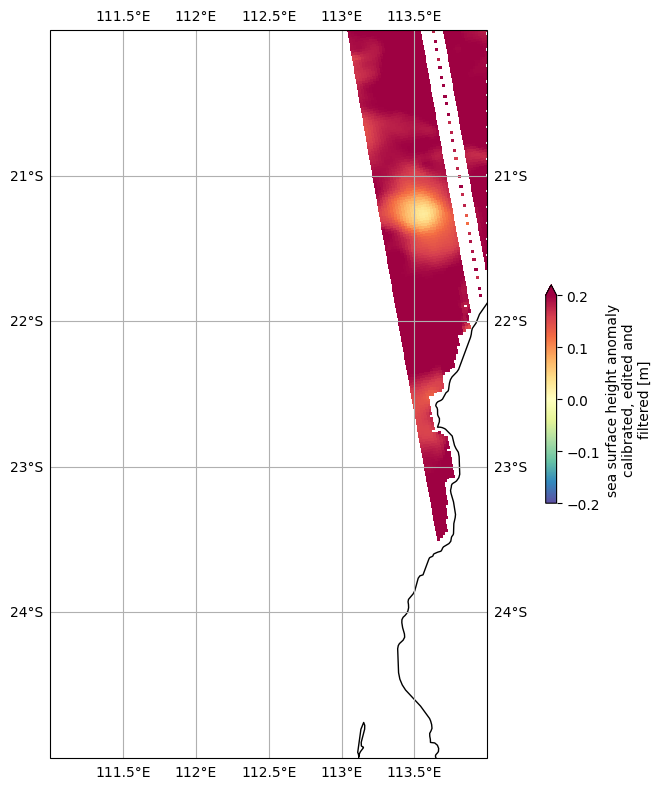

In [101]:
downloaded_files = ftp_download_files(
    ftp_path, level, variant, cycle_numbers, pass_numbers, output_dir, only_last=True
)

print("Downloaded:", downloaded_files)

# 后续裁剪 + 画图（如果需要）
variables = ['time', 'ssha_filtered']
localbox = [111, 114, -25, -20]

subset_filenames = subset_files(downloaded_files, variables, localbox[:2], localbox[2:], output_dir)
if subset_filenames:
    plot_datasets(subset_filenames, 'ssha_filtered', extent=localbox)
    plt.tight_layout(); plt.show()
else:
    print("No subset files to plot.")


In [102]:
subset_filenames = subset_files(downloaded_files, variables, localbox[:2], localbox[2:], output_dir)

Subset dataset: downloads/SWOT_L3_LR_SSH_Expert_029_062_20250226T145417_20250226T154543_v2.0.1.nc
Store subset: subset_SWOT_L3_LR_SSH_Expert_029_062_20250226T145417_20250226T154543_v2.0.1.nc


/tmp/ipython-input-871737252.py:117: SerializationWarning: saving variable latitude with floating point data as an integer dtype without any _FillValue to use for NaNs
  return [subset_file for subset_file in [_subset_ds(f, variables, lon_range, lat_range, output_dir) for f in filenames] if subset_file is not None]
/tmp/ipython-input-871737252.py:117: SerializationWarning: saving variable longitude with floating point data as an integer dtype without any _FillValue to use for NaNs
  return [subset_file for subset_file in [_subset_ds(f, variables, lon_range, lat_range, output_dir) for f in filenames] if subset_file is not None]


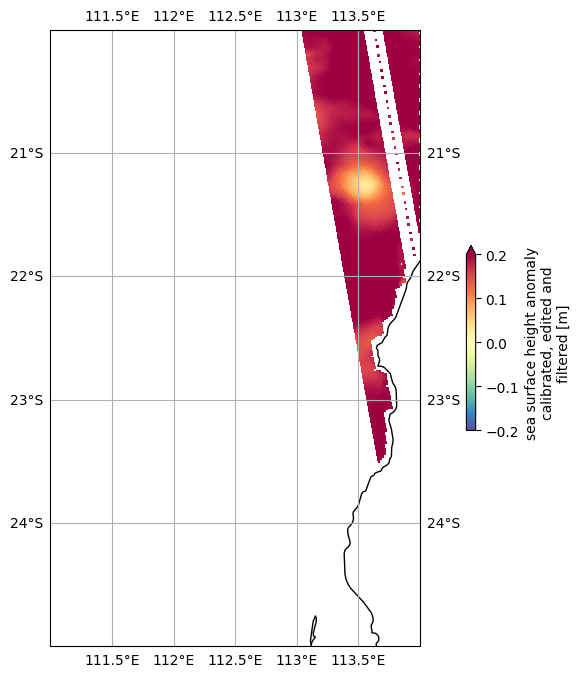

In [103]:
plot_datasets(subset_filenames, 'ssha_filtered', extent=localbox)